# 03 — Classical ML benchmark (Phase 3)

Six classical models (Decision Tree, Random Forest, XGBoost, CatBoost, Logistic
Regression, SVM) tuned and evaluated on all three datasets — **18 experiments**.

The compute is done by a script, not this notebook:

```bash
python -m src.experiments.run_classical --all
```

Each run uses a leakage-safe `imblearn` Pipeline (impute → scale → SMOTE → model)
tuned with `RandomizedSearchCV` (5-fold, F1). This notebook just **reads and
visualizes** `results/metrics_ml.csv` and the saved figures.

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.config import (
    METRICS_ML_CSV, CONFUSION_MATRICES_DIR, ROC_CURVES_DIR, PLOTS_FEATURE_IMPORTANCE_DIR,
)
sns.set_theme(style="whitegrid")
DS_ORDER = ["uci", "mendeley", "iscx"]
print("setup ok")

setup ok


## 1. Results table (sorted by F1)

In [2]:
df = pd.read_csv(METRICS_ML_CSV)
print(f"{len(df)} experiments")
df.sort_values("f1", ascending=False).reset_index(drop=True)

18 experiments


,model,dataset,accuracy,precision,recall,f1,auc_roc,train_time_s,inference_time_ms_per_sample
0,XGBoost,iscx,0.9870,0.9929,0.9807,0.9867,0.9990,47.5201,0.005157
1,CatBoost,iscx,0.9844,0.9920,0.9763,0.9841,0.9988,212.5145,0.003236
2,RandomForest,iscx,0.9844,0.9911,0.9772,0.9841,0.9991,424.1557,0.060316
3,SVM,iscx,0.9814,0.9858,0.9763,0.9810,0.9965,108.4910,0.086242
4,DecisionTree,iscx,0.9727,0.9864,0.9578,0.9719,0.9725,11.2189,0.002119
5,RandomForest,uci,0.9711,0.9699,0.9646,0.9673,0.9968,58.3852,0.066113
6,CatBoost,uci,0.9687,0.9723,0.9565,0.9643,0.9970,60.0612,0.002604
7,SVM,uci,0.9675,0.9789,0.9469,0.9627,0.9961,49.1253,0.089371
8,XGBoost,uci,0.9662,0.9722,0.9510,0.9615,0.9965,21.5106,0.003979
9,DecisionTree,uci,0.9644,0.9708,0.9483,0.9594,0.9772,4.7262,0.001948


## 2. F1 heatmap — models x datasets

Green = better. Lets you spot which models are consistent across datasets.

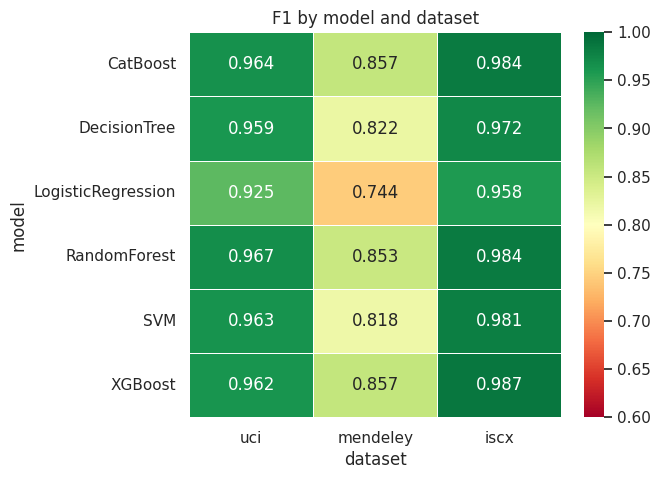

dataset,uci,mendeley,iscx
model,,,
CatBoost,0.9643,0.8571,0.9841
DecisionTree,0.9594,0.8218,0.9719
LogisticRegression,0.9247,0.7443,0.9575
RandomForest,0.9673,0.8531,0.9841
SVM,0.9627,0.8175,0.9810
XGBoost,0.9615,0.8571,0.9867


In [3]:
pivot = df.pivot(index="model", columns="dataset", values="f1")
pivot = pivot[[c for c in DS_ORDER if c in pivot.columns]]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.6, vmax=1.0,
            linewidths=0.5, ax=ax)
ax.set_title("F1 by model and dataset")
plt.show()
pivot

## 3. Best model per dataset

In [4]:
present = [d for d in DS_ORDER if d in df["dataset"].unique()]
for ds in present:
    b = df[df["dataset"] == ds].sort_values("f1", ascending=False).iloc[0]
    print(f"{ds:9s} best: {b['model']:18s} F1={b['f1']:.4f}  AUC={b['auc_roc']:.4f}  acc={b['accuracy']:.4f}")

uci       best: RandomForest       F1=0.9673  AUC=0.9968  acc=0.9711
mendeley  best: XGBoost            F1=0.8571  AUC=0.9595  acc=0.8921
iscx      best: XGBoost            F1=0.9867  AUC=0.9990  acc=0.9870


## 4. Diagnostics — confusion matrix + ROC for the best model on each dataset

=== uci: RandomForest ===


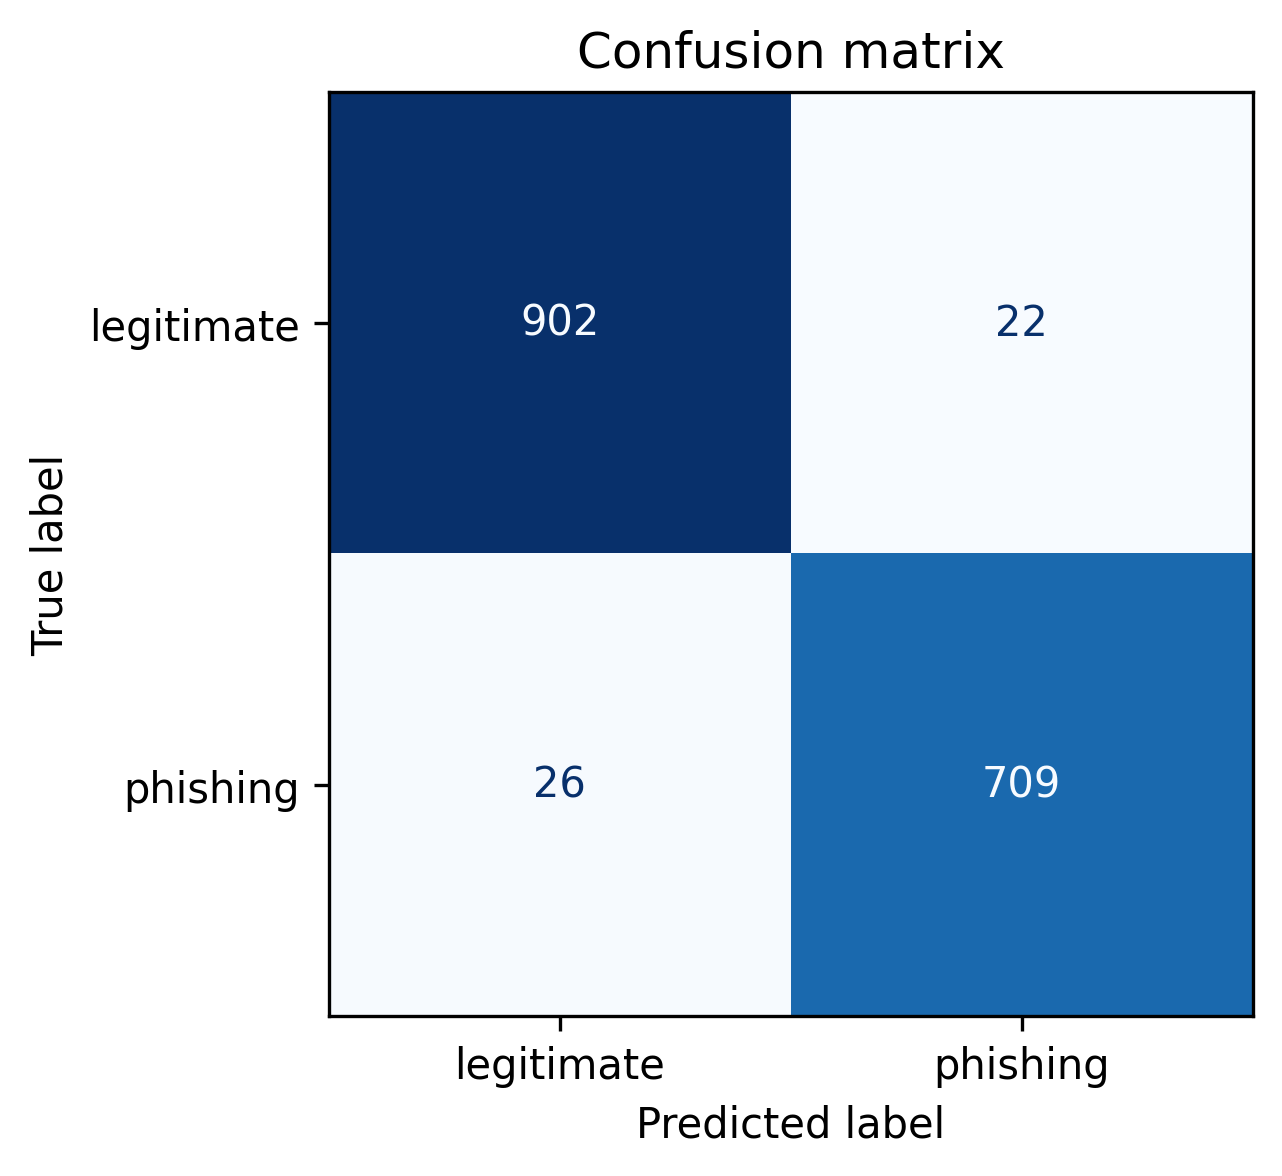

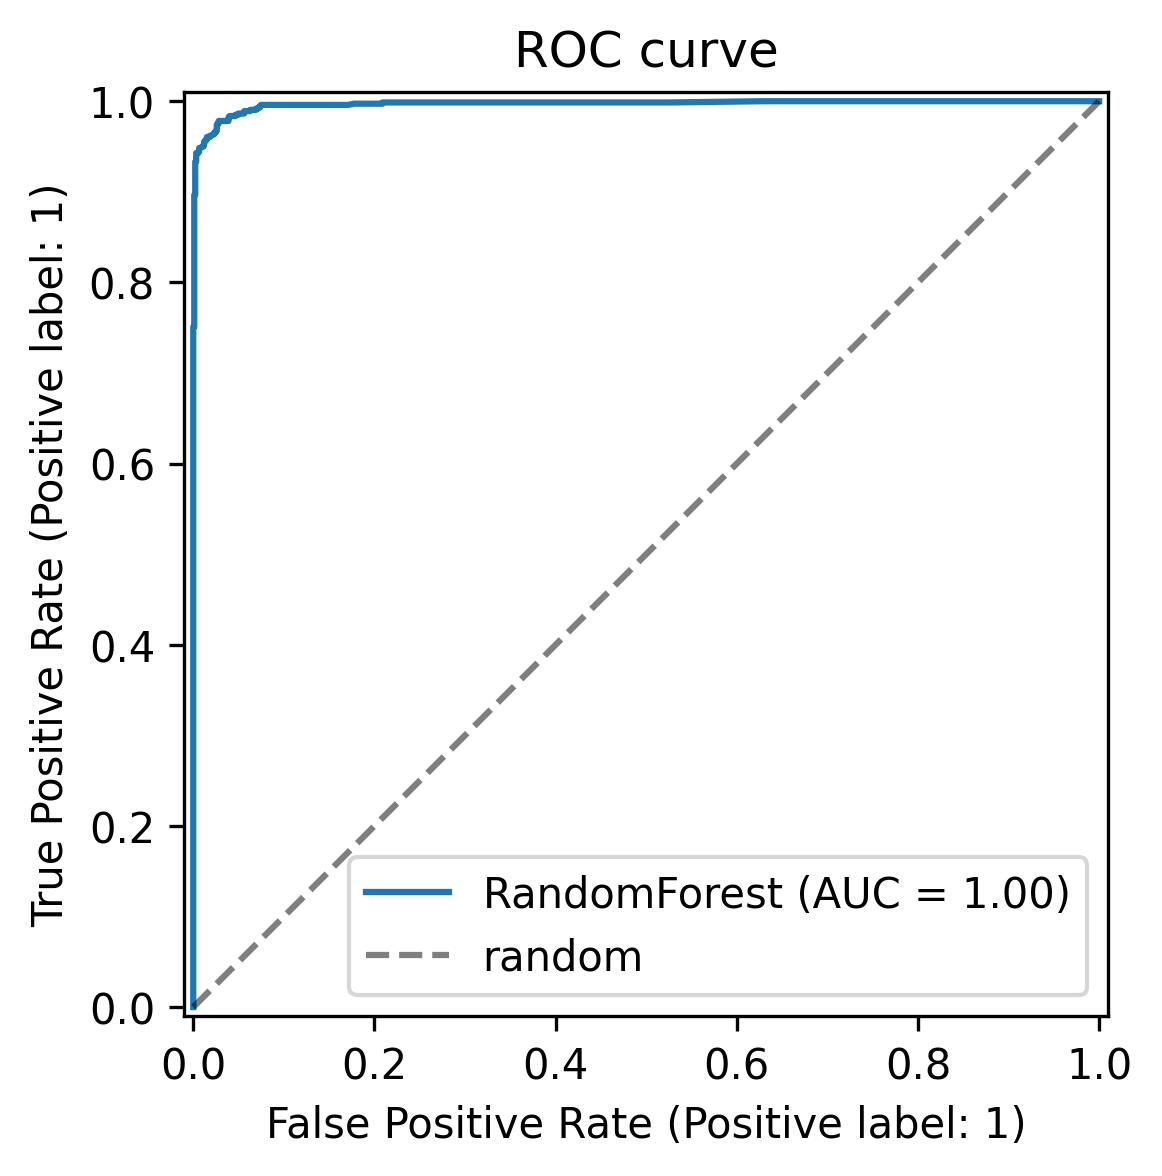

=== mendeley: XGBoost ===


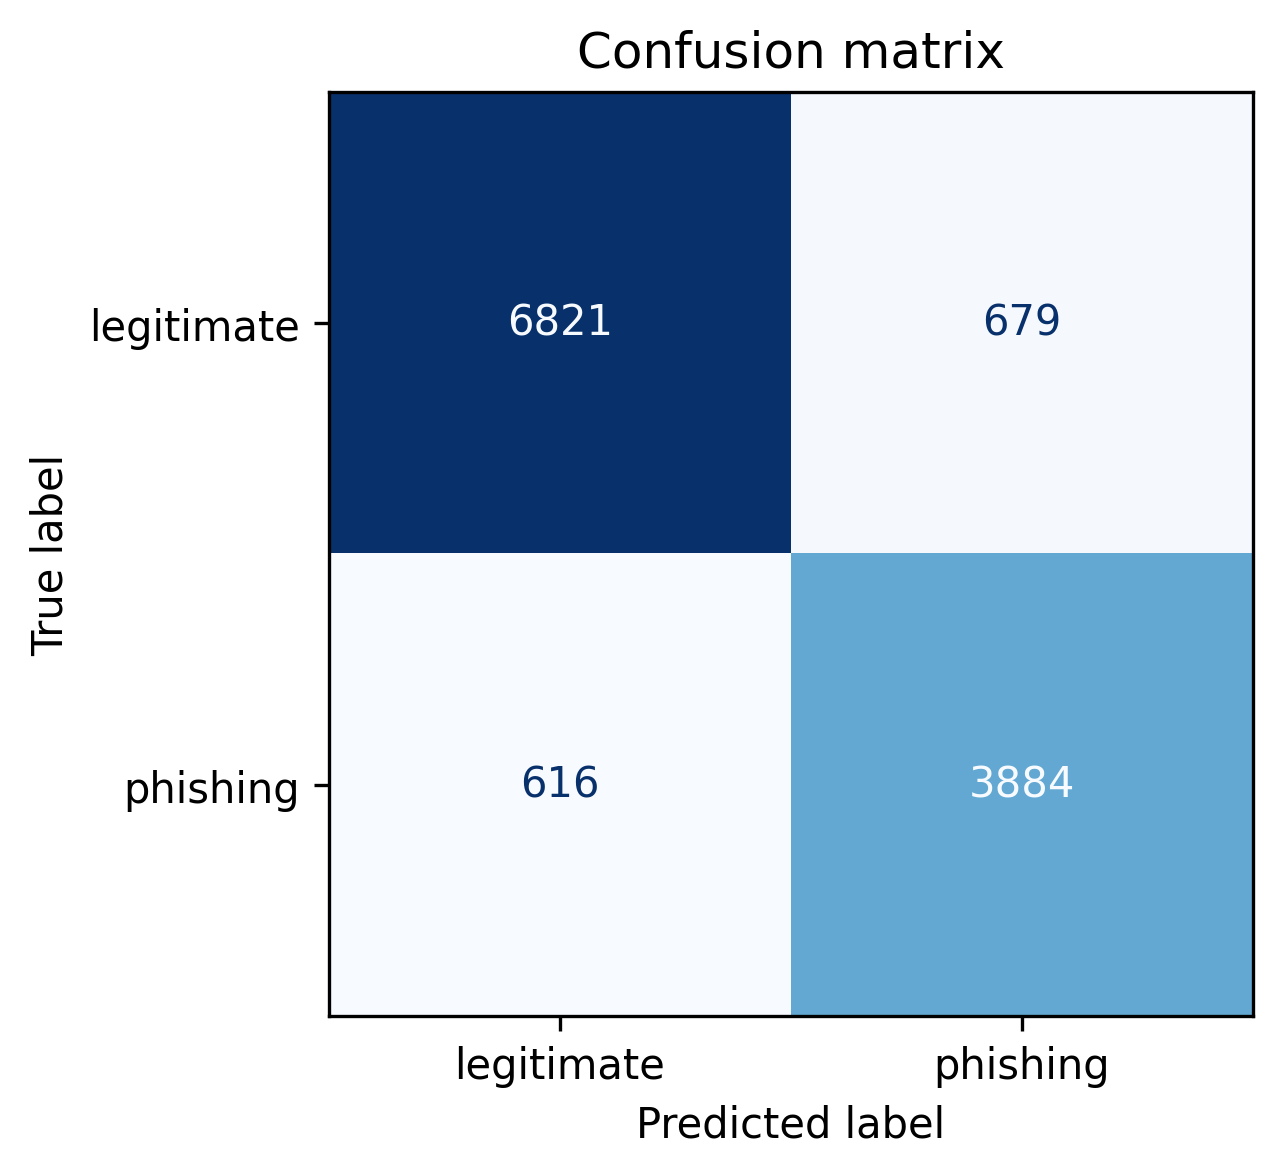

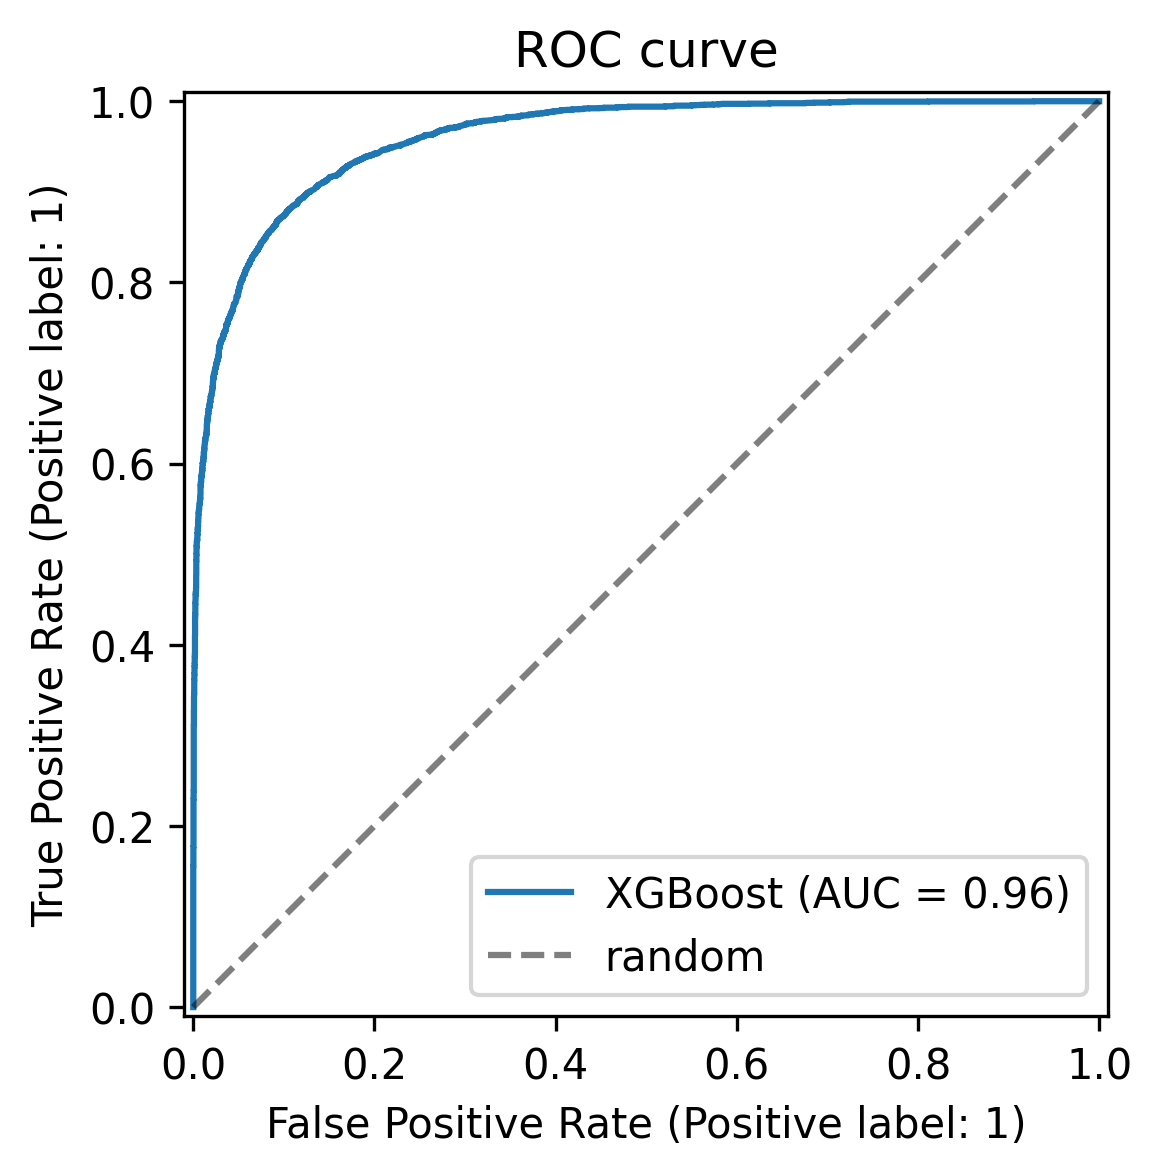

=== iscx: XGBoost ===


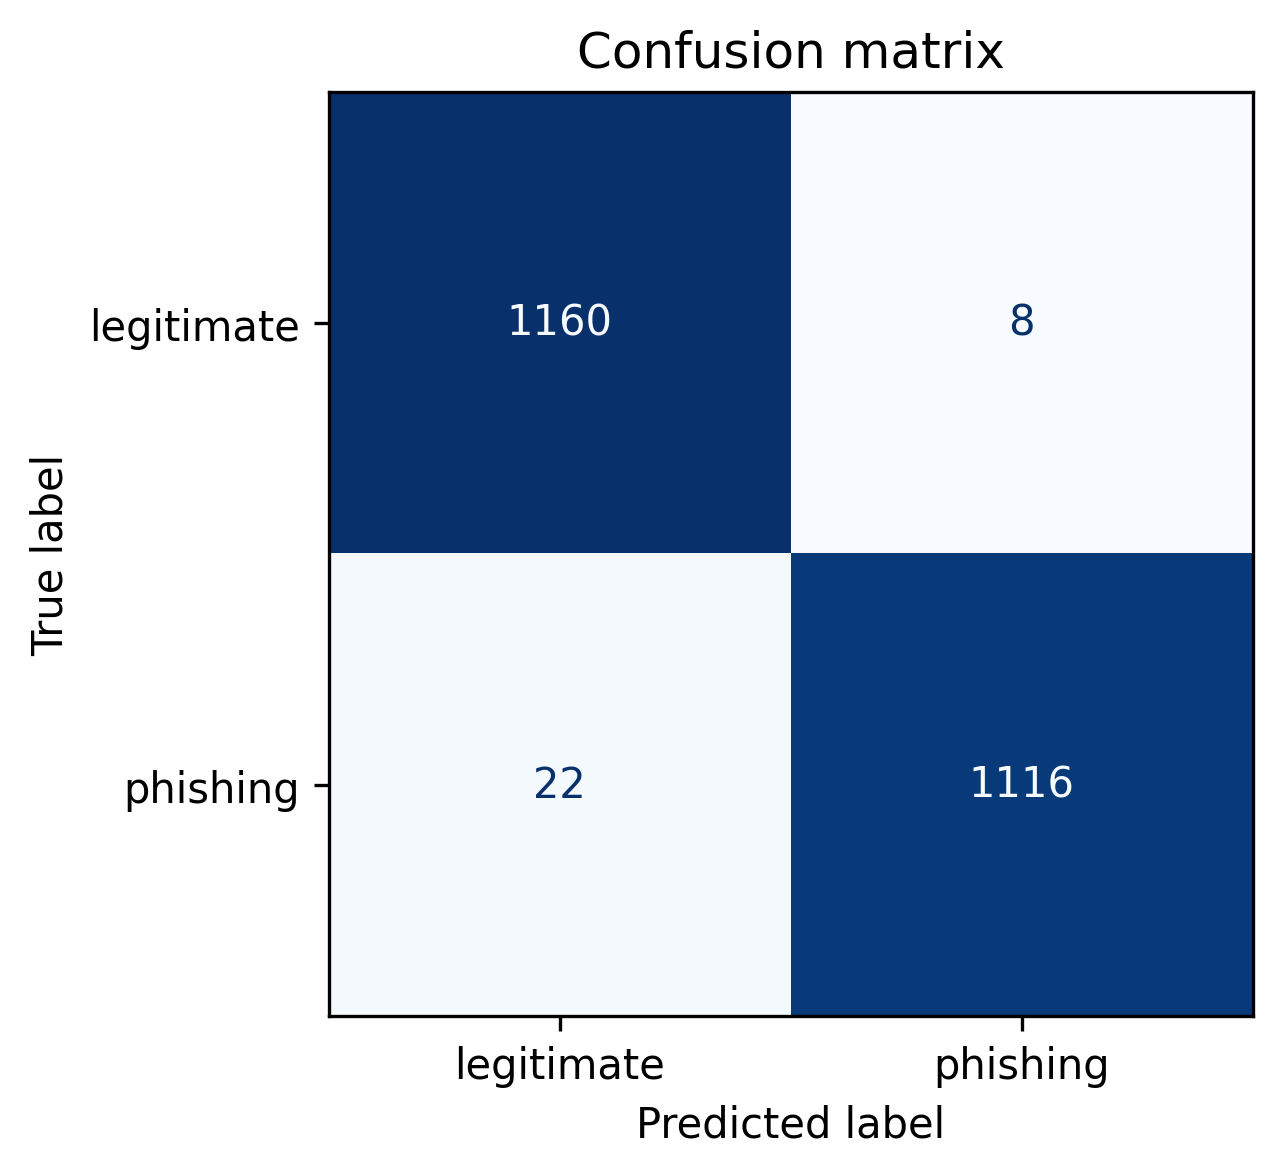

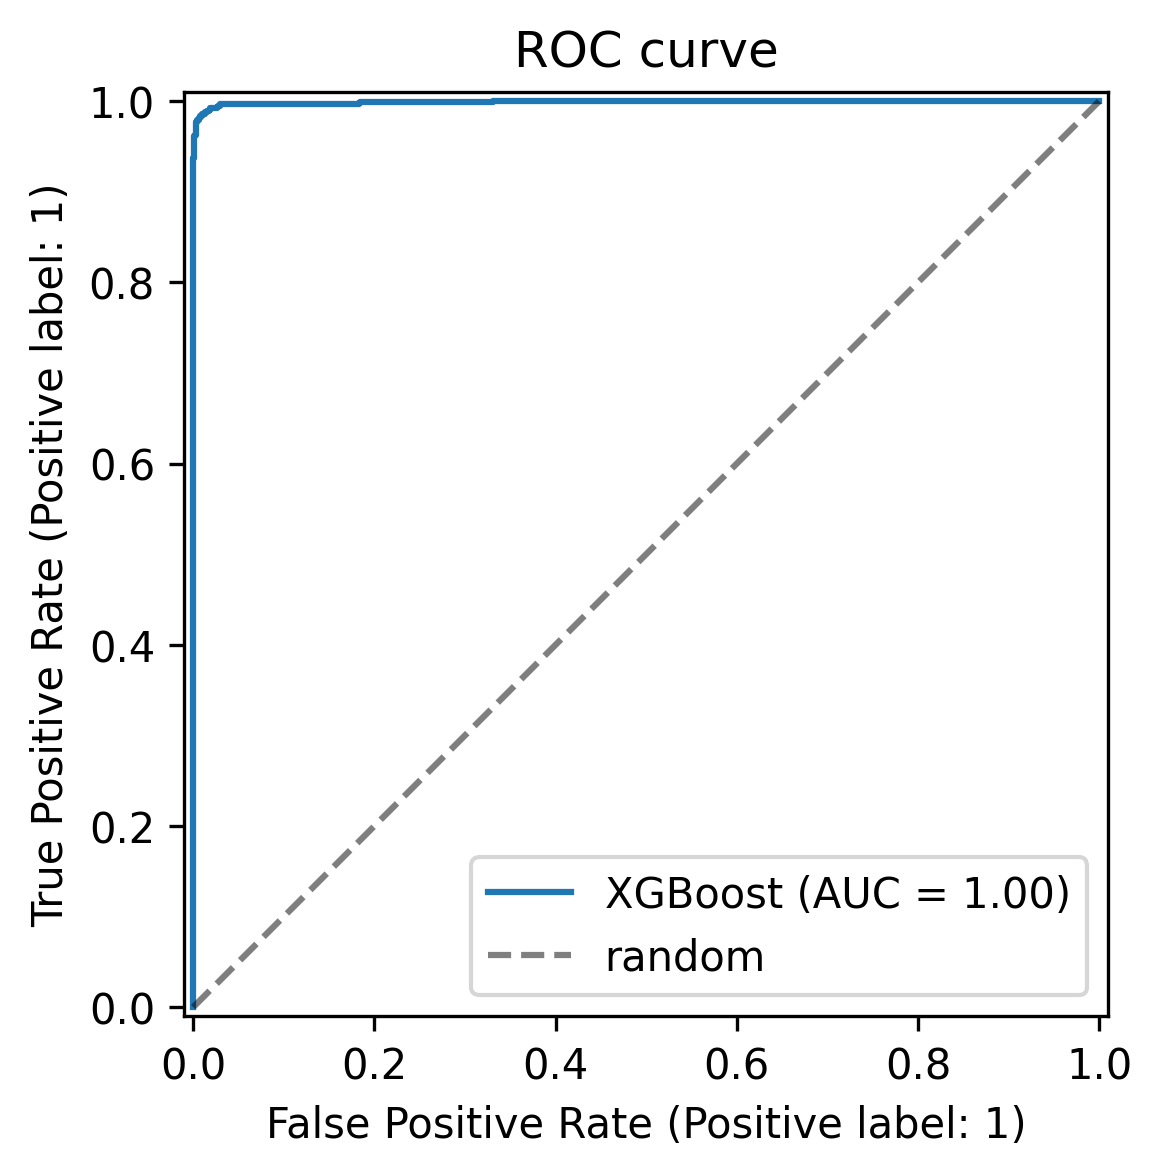

In [5]:
for ds in present:
    best = df[df["dataset"] == ds].sort_values("f1", ascending=False).iloc[0]["model"]
    print(f"=== {ds}: {best} ===")
    for folder in (CONFUSION_MATRICES_DIR, ROC_CURVES_DIR):
        p = folder / f"{best}_{ds}.png"
        if p.exists():
            display(Image(filename=str(p)))

## 5. Feature importance (Random Forest, per dataset)

Which URL/structured features drive detection. XGBoost and CatBoost importances are saved alongside in `plots/feature_importance/`.

=== RandomForest feature importance — uci ===


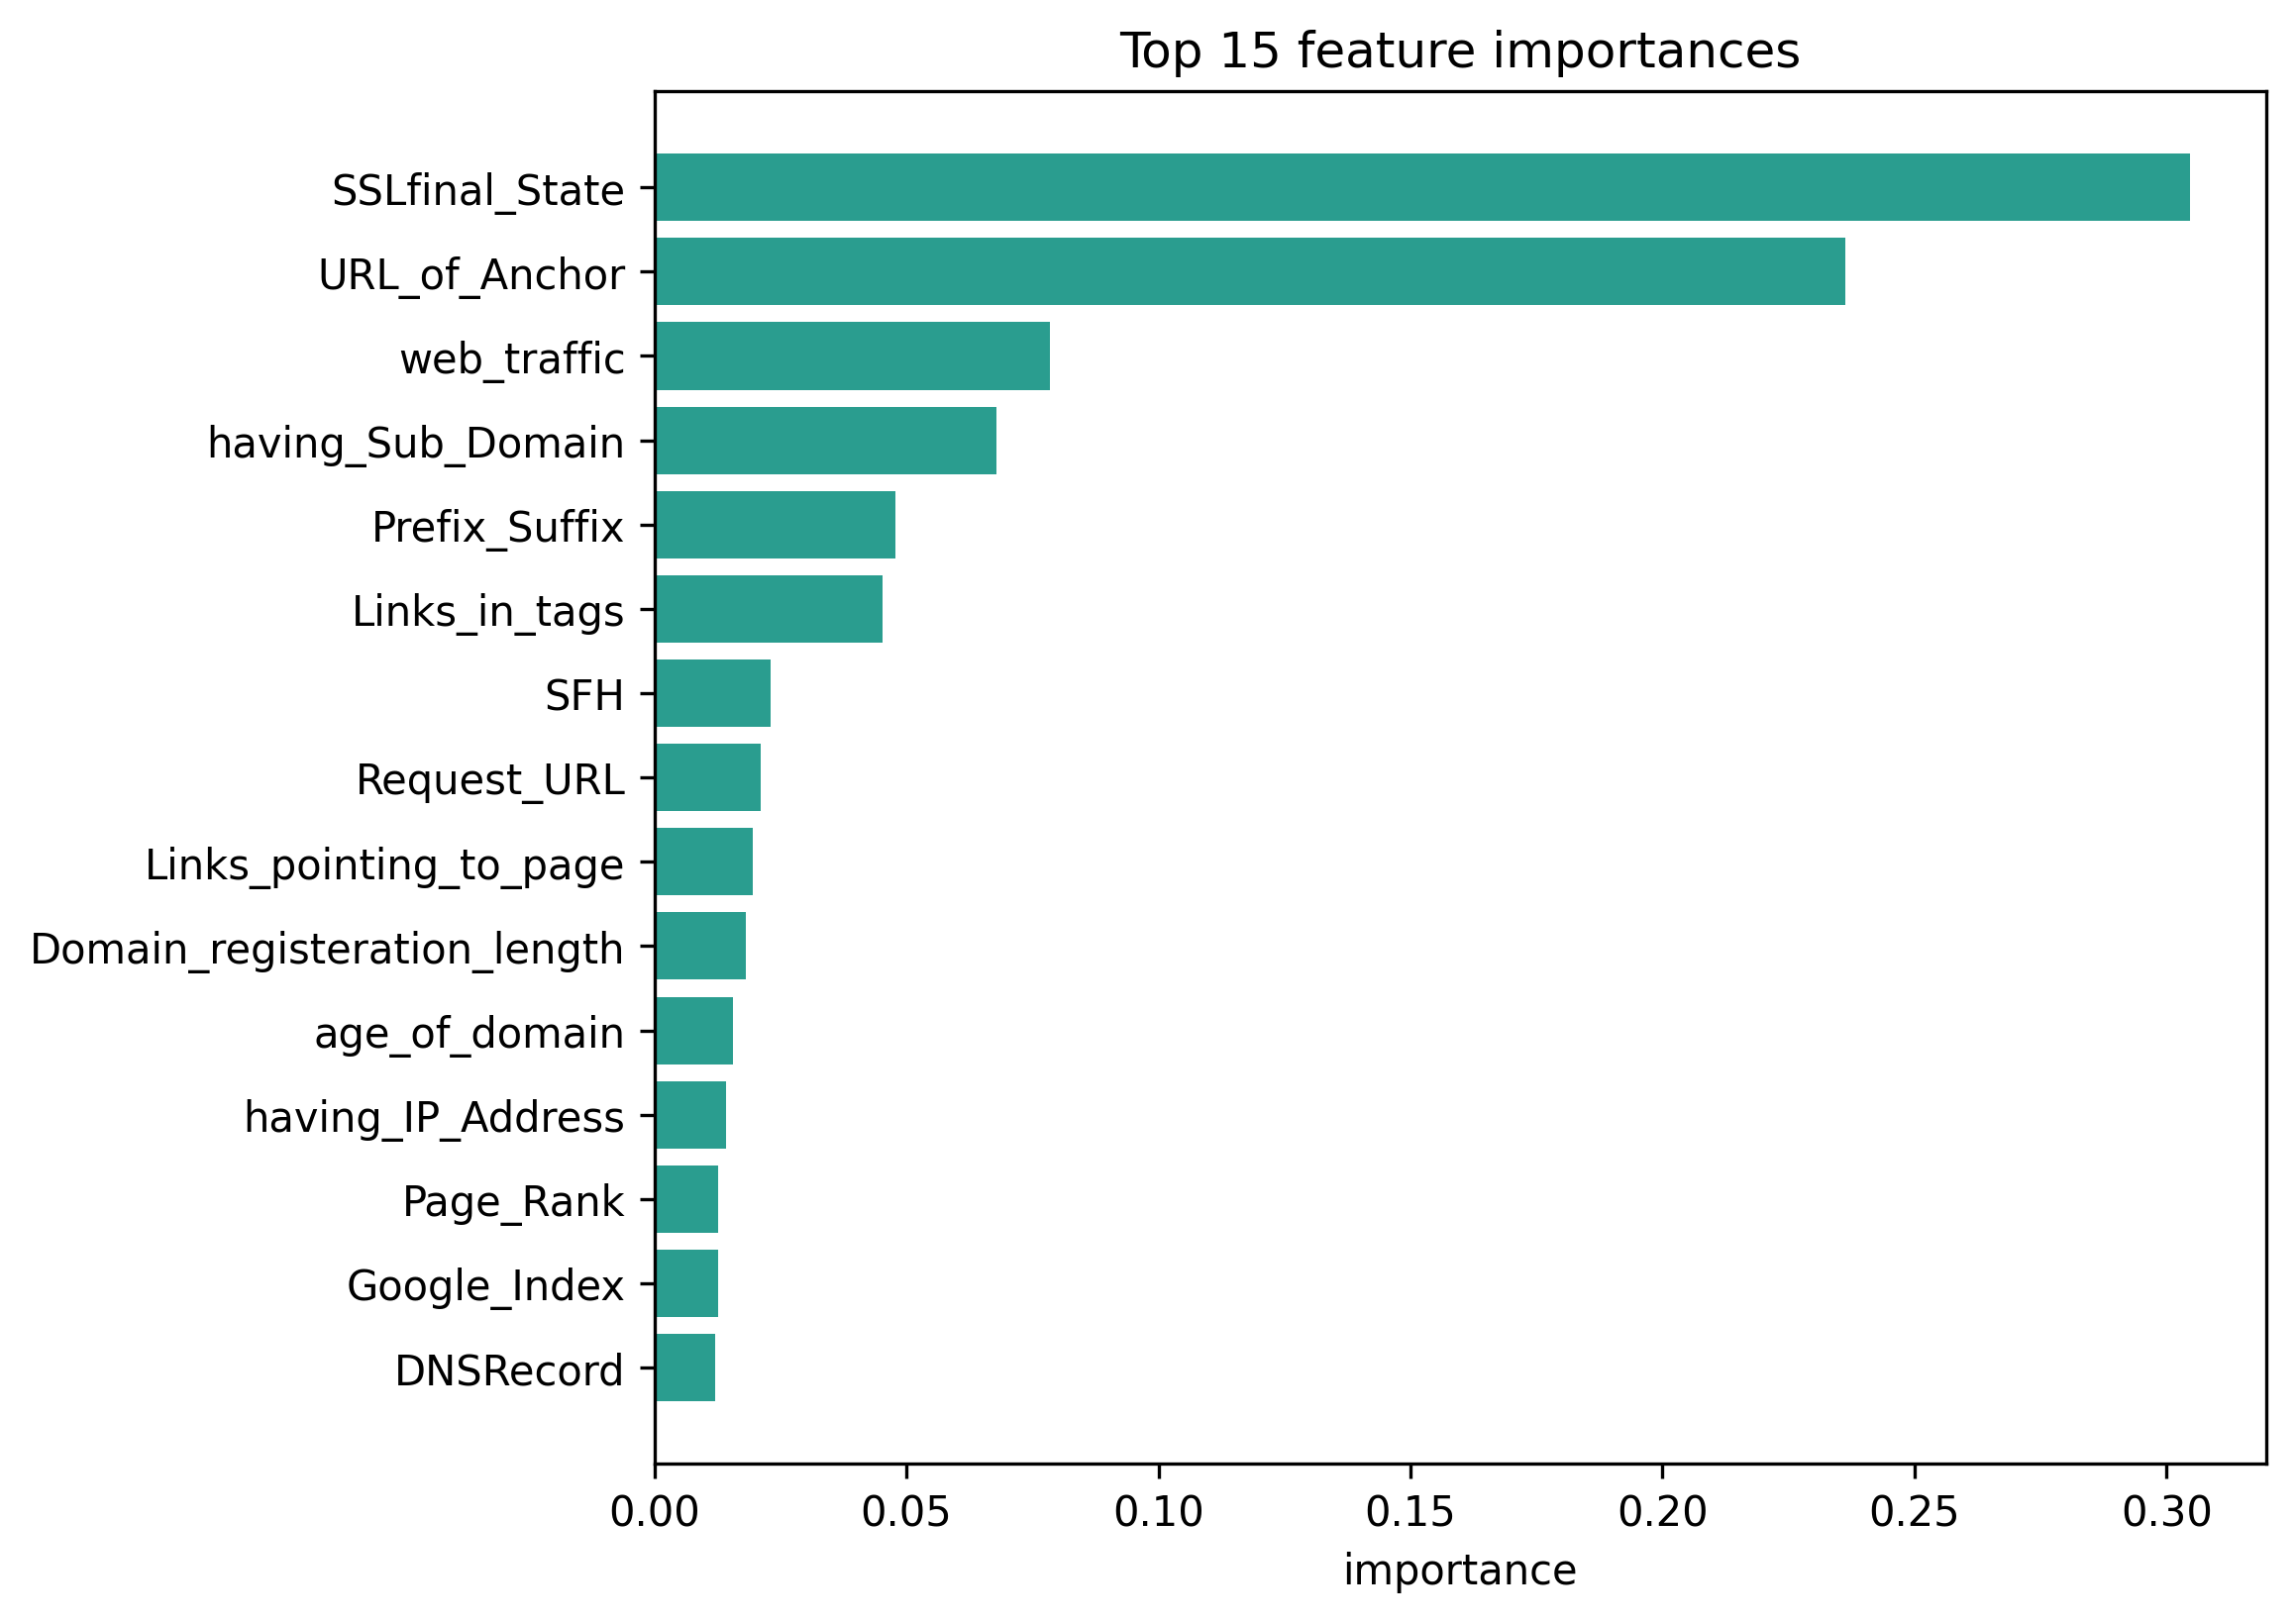

=== RandomForest feature importance — mendeley ===


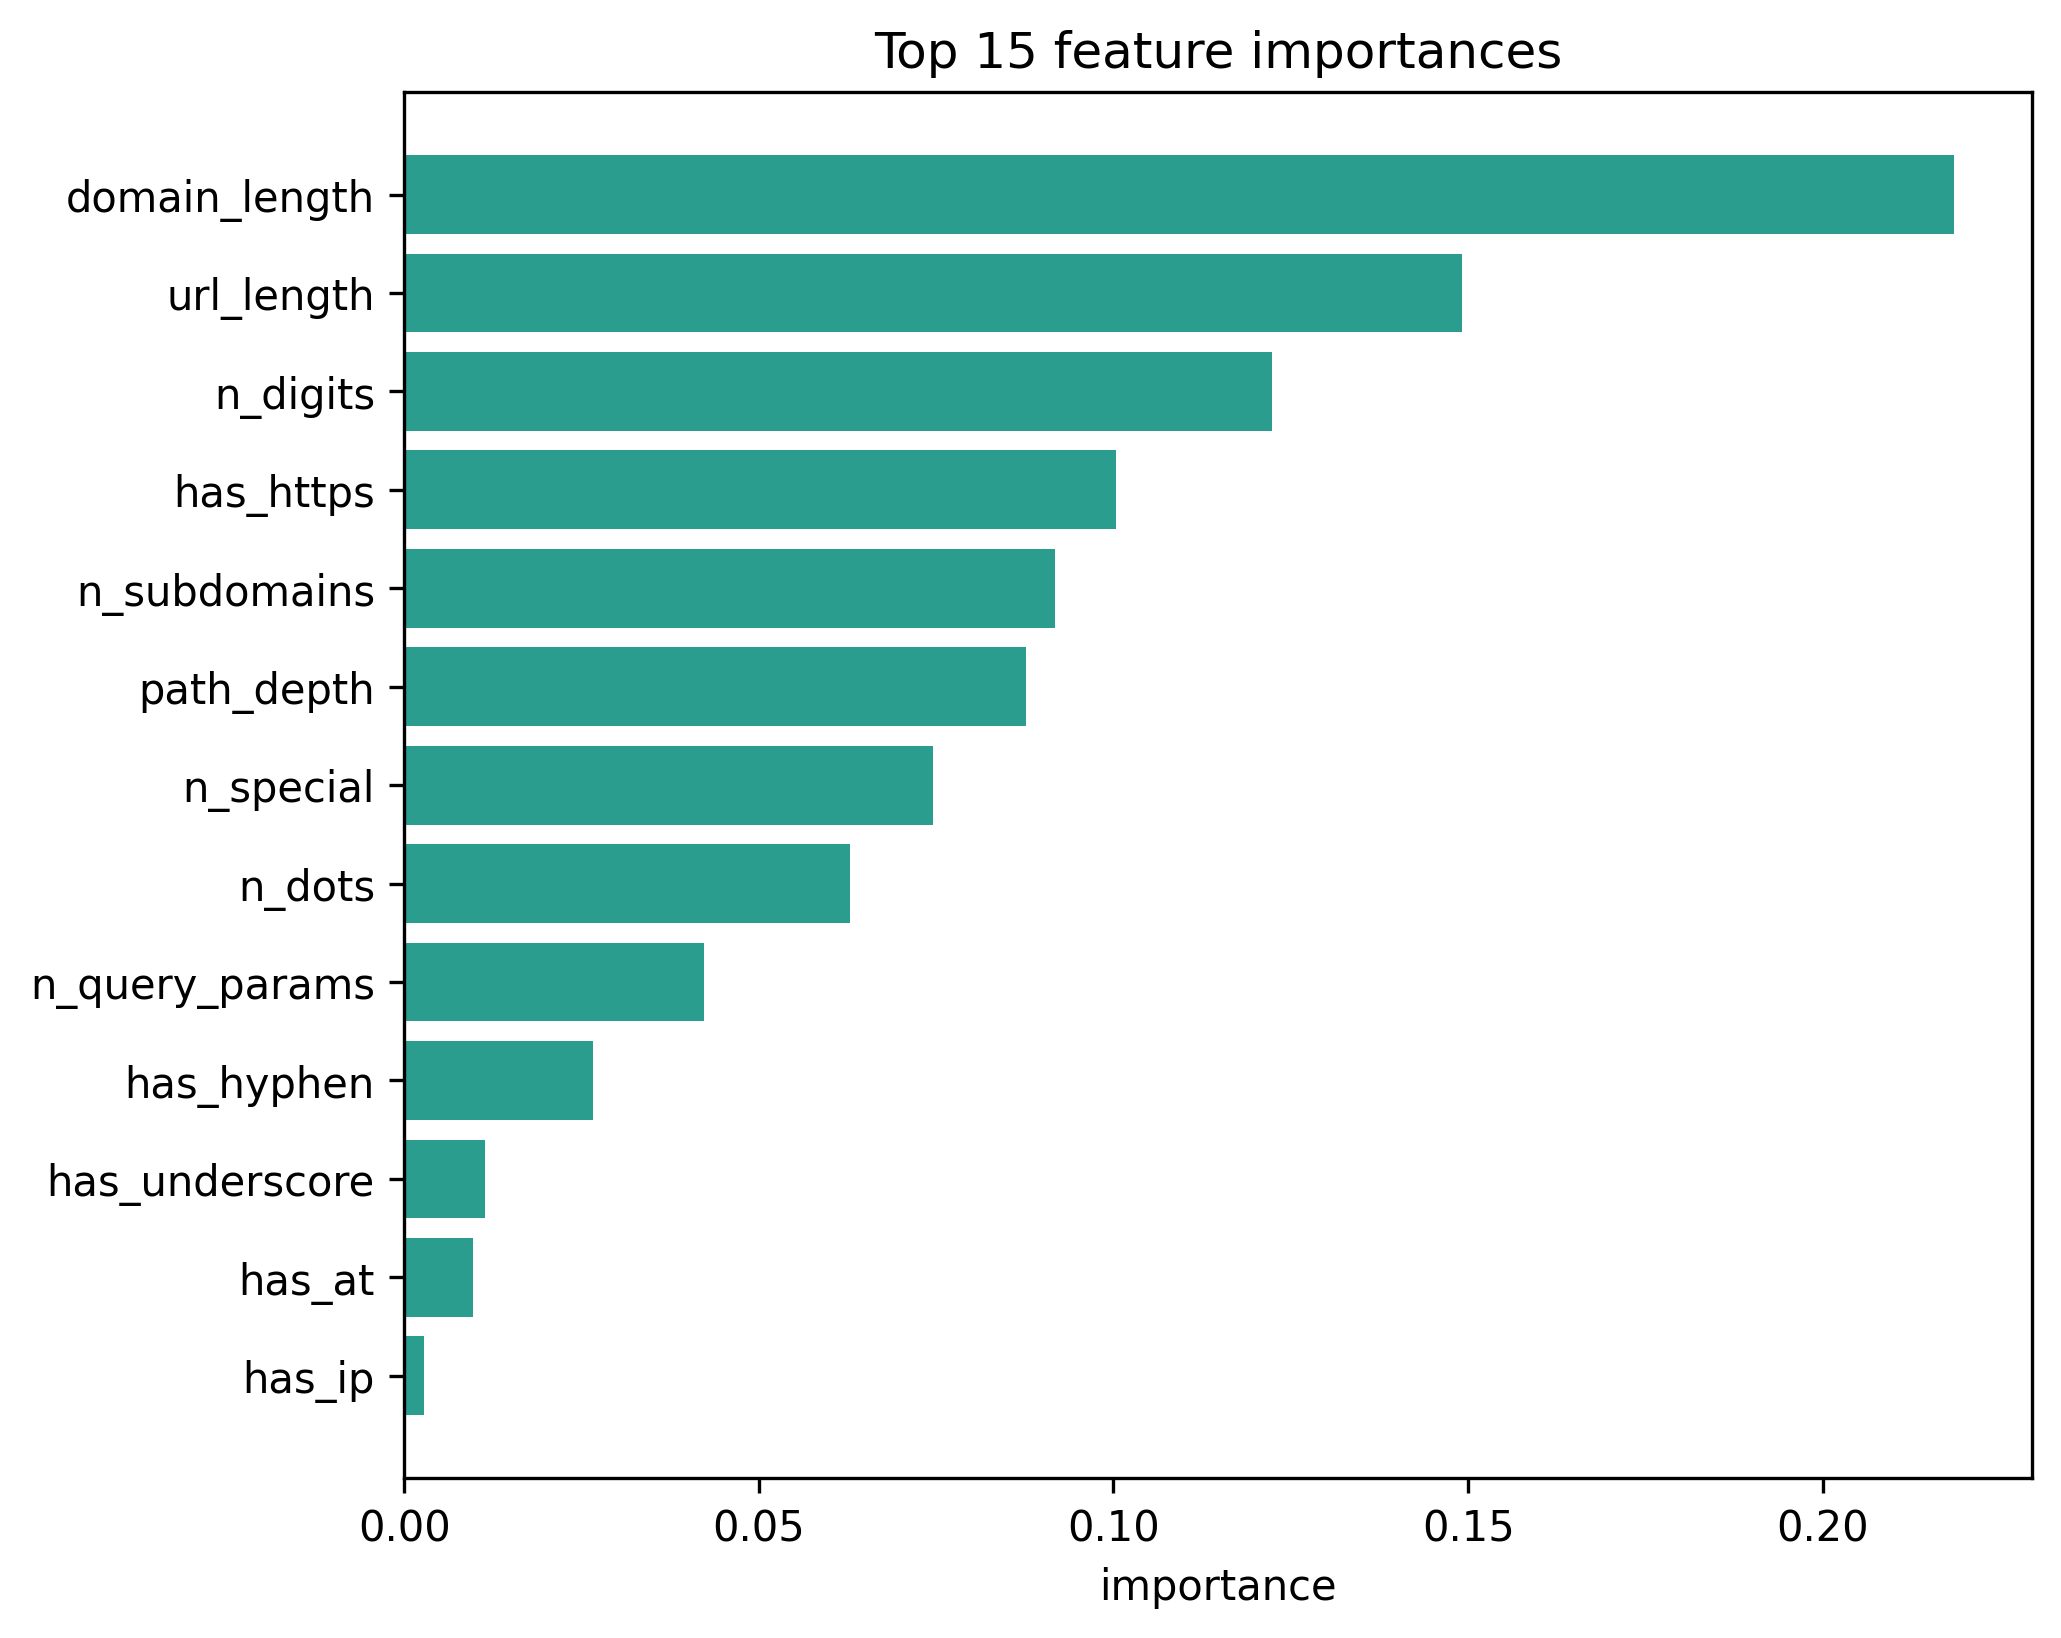

=== RandomForest feature importance — iscx ===


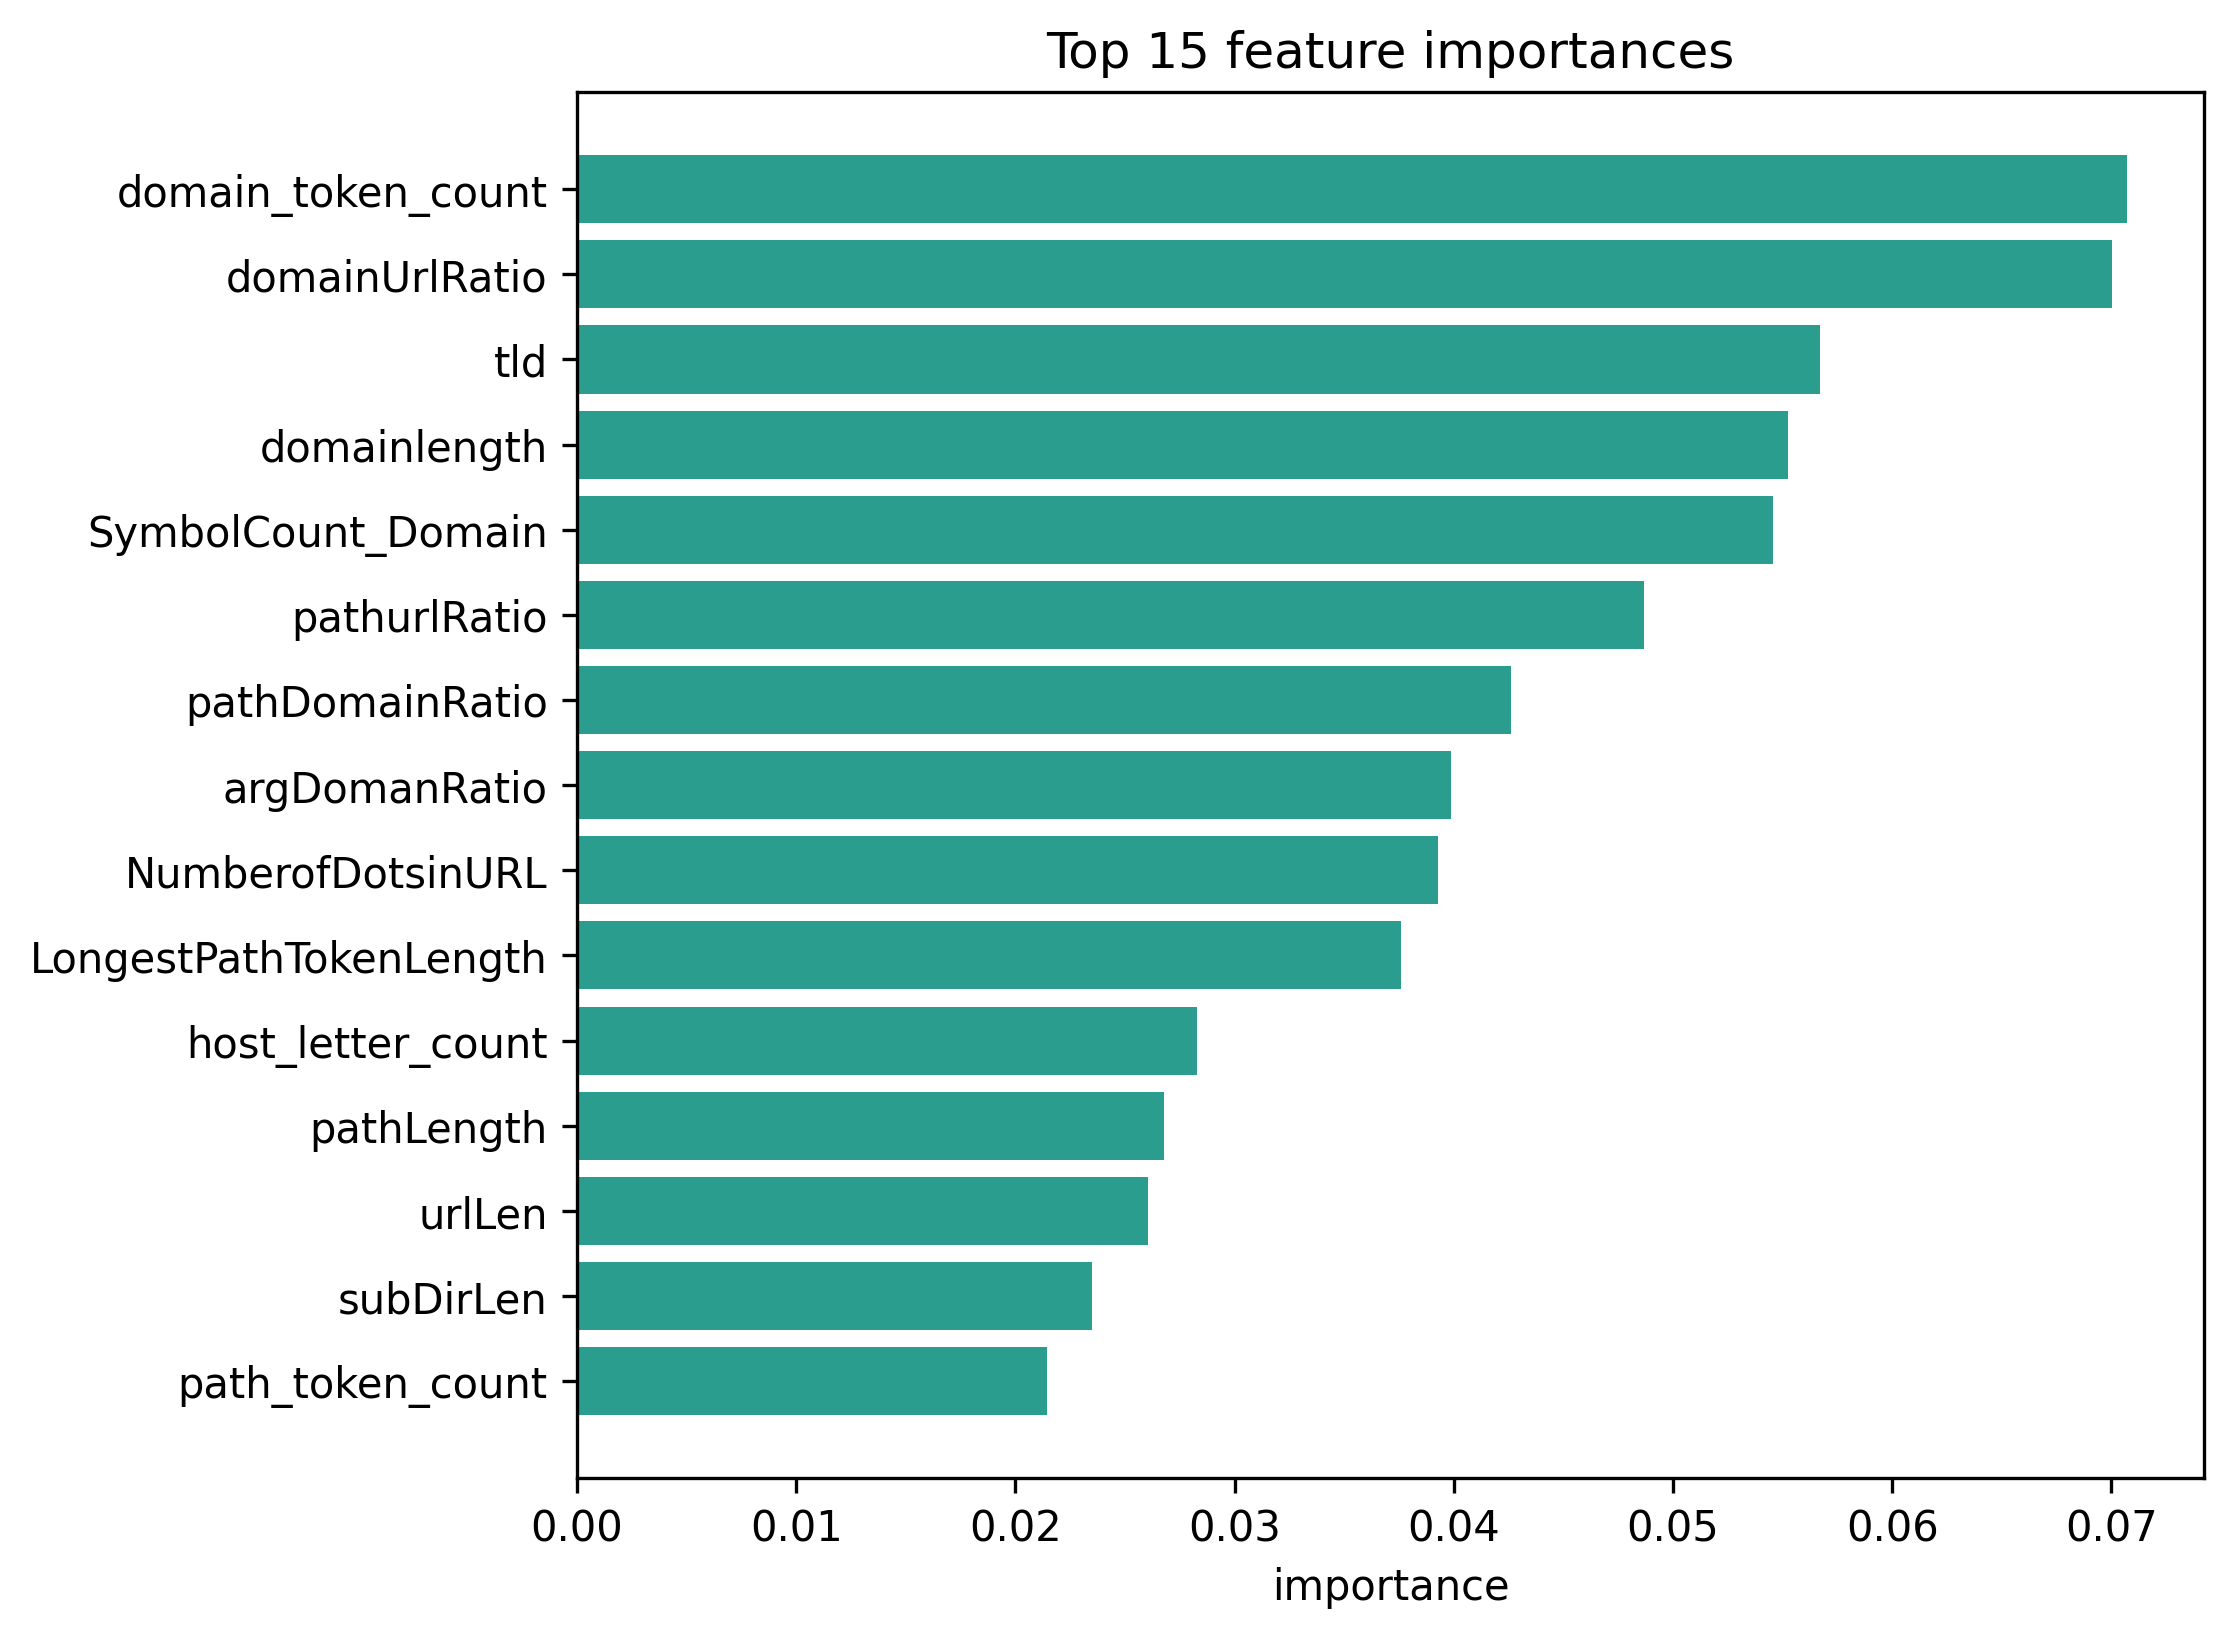

In [6]:
for ds in present:
    p = PLOTS_FEATURE_IMPORTANCE_DIR / f"RandomForest_{ds}.png"
    if p.exists():
        print(f"=== RandomForest feature importance — {ds} ===")
        display(Image(filename=str(p)))

## 6. Exit criterion ✓

`metrics_ml.csv` holds 18 rows (6 models × 3 datasets); every experiment has a
saved confusion matrix and ROC curve; RF/XGBoost/CatBoost have feature-importance
plots. Next: Phase 4 (Deep Learning on the raw URL characters).